# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train (1).csv")
df_test = pd.read_csv("test (1).csv")

# 2. EDA (Exploratory Data Analysis)

## 2.1 General

In [3]:
print(f"|{'# of Null in Train':>20}|")
print(f"{df.isnull().sum()}|")

|  # of Null in Train|
ID                    0
Edad                  0
Tipo_Trabajo          0
Estado_Civil          0
Educacion             0
Incumplimiento        0
Vivienda              0
Consumo               0
Contacto              0
Mes                   0
Dias                  0
Campana               0
Dias_Ultima_Camp      0
No_Contactos          0
Resultado_Anterior    0
emp_var_rate          0
cons_price_idx        0
cons_conf_idx         0
euribor3m             0
nr_employed           0
y                     0
dtype: int64|


In [4]:
print("Types of variables in Train:")
print(df.dtypes)

Types of variables in Train:
ID                      int64
Edad                    int64
Tipo_Trabajo              str
Estado_Civil              str
Educacion                 str
Incumplimiento            str
Vivienda                  str
Consumo                   str
Contacto                  str
Mes                       str
Dias                      str
Campana                 int64
Dias_Ultima_Camp        int64
No_Contactos            int64
Resultado_Anterior        str
emp_var_rate          float64
cons_price_idx        float64
cons_conf_idx         float64
euribor3m             float64
nr_employed           float64
y                       int64
dtype: object


## 2.2 Histograms

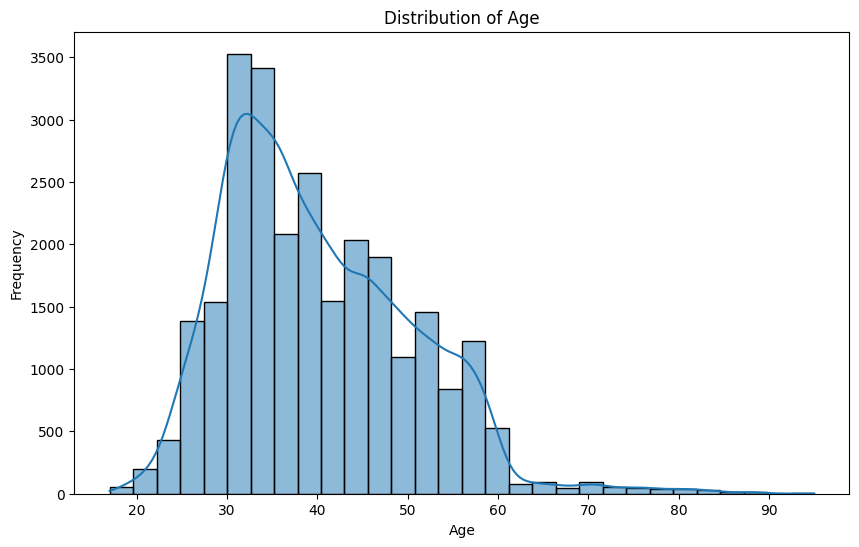

In [5]:
# Distribution of Age variable
plt.figure(figsize=(10, 6))
sns.histplot(df["Edad"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

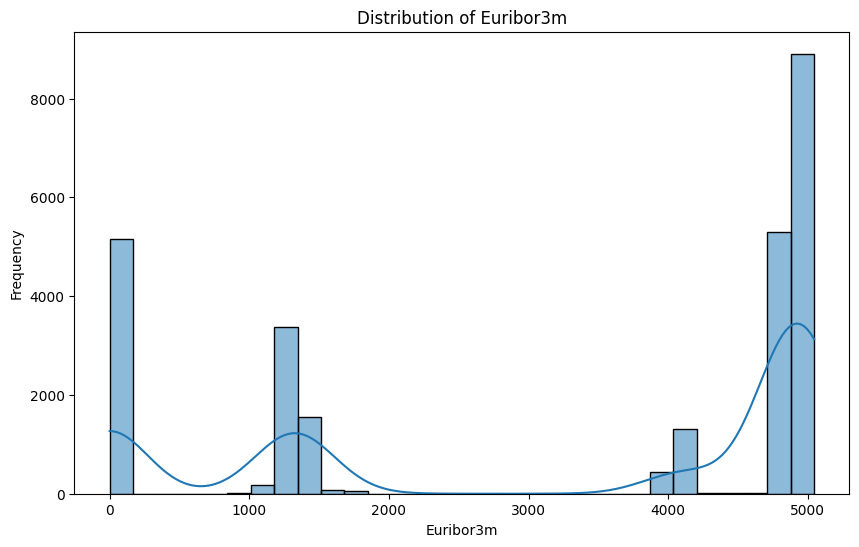

In [6]:
# Distribution of euribor3m variable
plt.figure(figsize=(10, 6))
sns.histplot(df["euribor3m"], bins=30, kde=True)
plt.title("Distribution of Euribor3m")
plt.xlabel("Euribor3m")
plt.ylabel("Frequency")
plt.show()

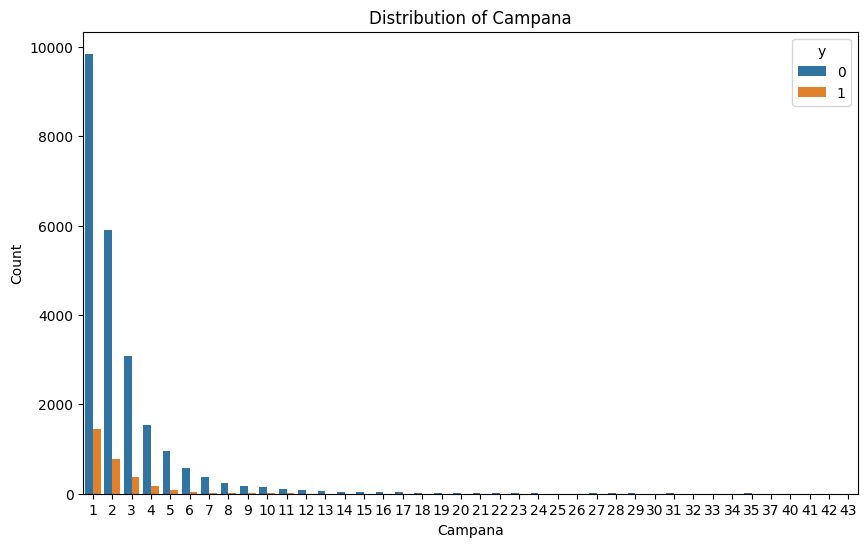

In [7]:
# Histogram of Campana variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Campana", data=df, hue="y")
plt.title("Distribution of Campana")
plt.xlabel("Campana")
plt.ylabel("Count")
plt.show()

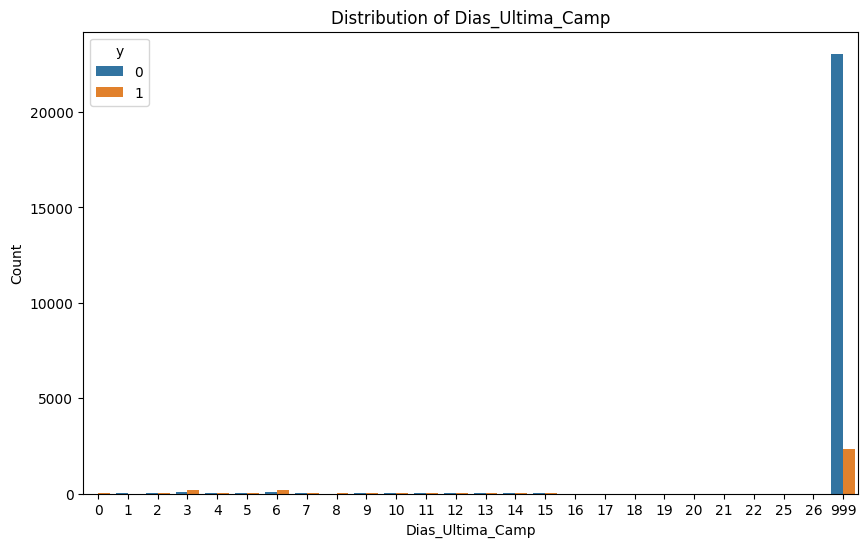

In [8]:
# Histogram of Dias_Ultima_Camp variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Dias_Ultima_Camp", data=df, hue="y")
plt.title("Distribution of Dias_Ultima_Camp")
plt.xlabel("Dias_Ultima_Camp")
plt.ylabel("Count")
plt.show()

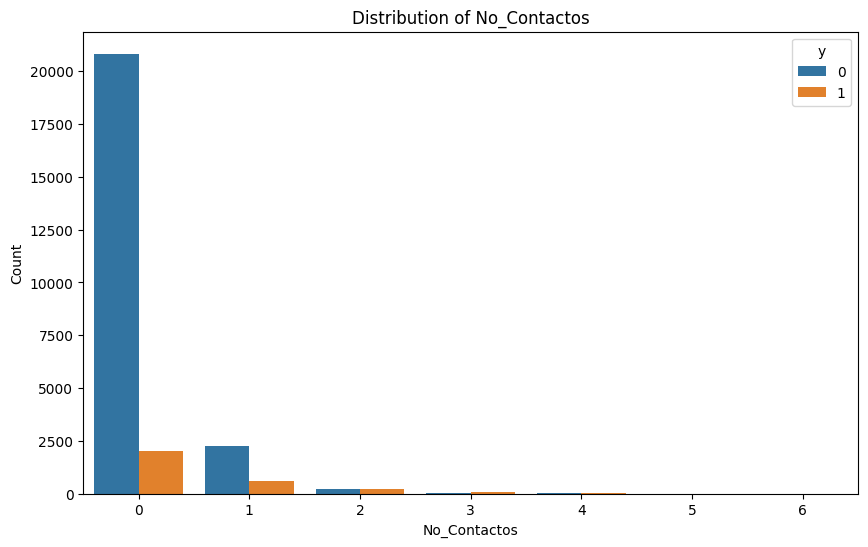

In [9]:
# Histogram of No_Contactos variable
plt.figure(figsize=(10, 6))
sns.countplot(x="No_Contactos", data=df, hue="y")
plt.title("Distribution of No_Contactos")
plt.xlabel("No_Contactos")
plt.ylabel("Count")
plt.show()

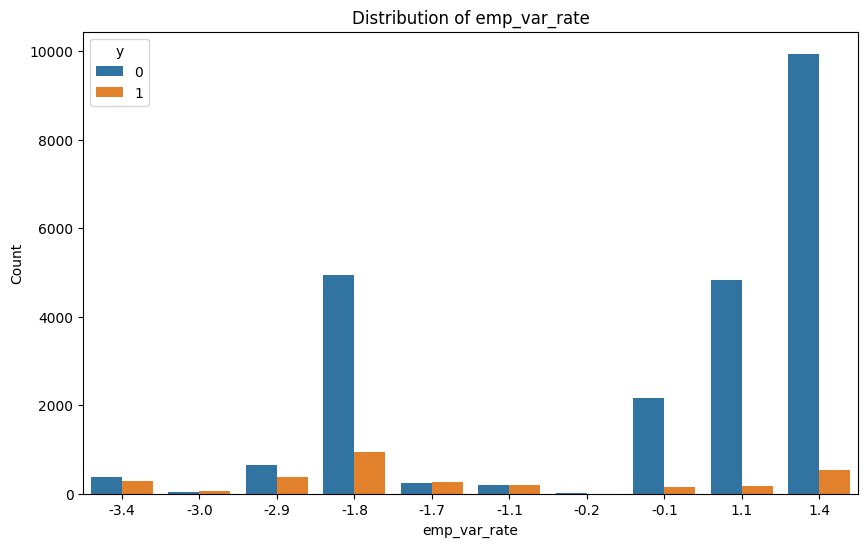

In [10]:
# Histogram of emp_var_rate variable
plt.figure(figsize=(10, 6))
sns.countplot(x="emp_var_rate", data=df, hue="y")
plt.title("Distribution of emp_var_rate")
plt.xlabel("emp_var_rate")
plt.ylabel("Count")
plt.show()

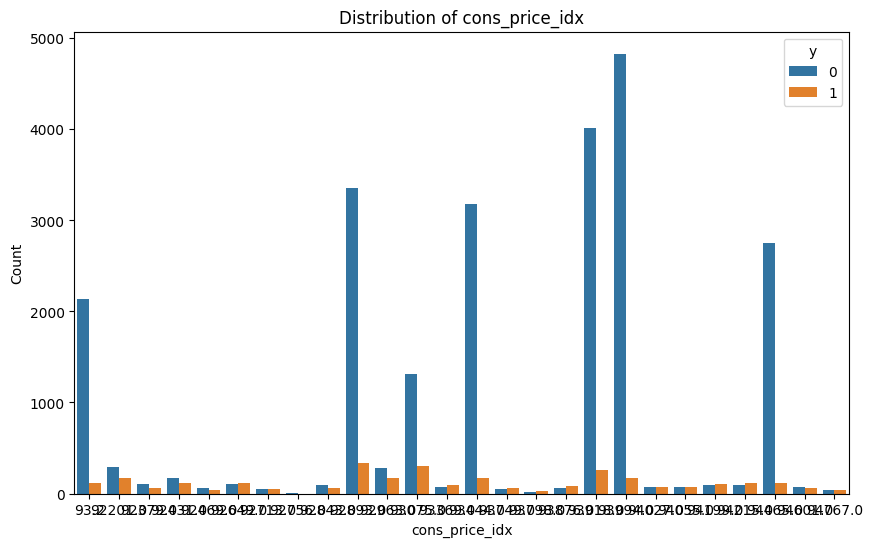

In [11]:
# Histogram of cons_price_idx variable
plt.figure(figsize=(10, 6))
sns.countplot(x="cons_price_idx", data=df, hue="y")
plt.title("Distribution of cons_price_idx")
plt.xlabel("cons_price_idx")
plt.ylabel("Count")
plt.show()

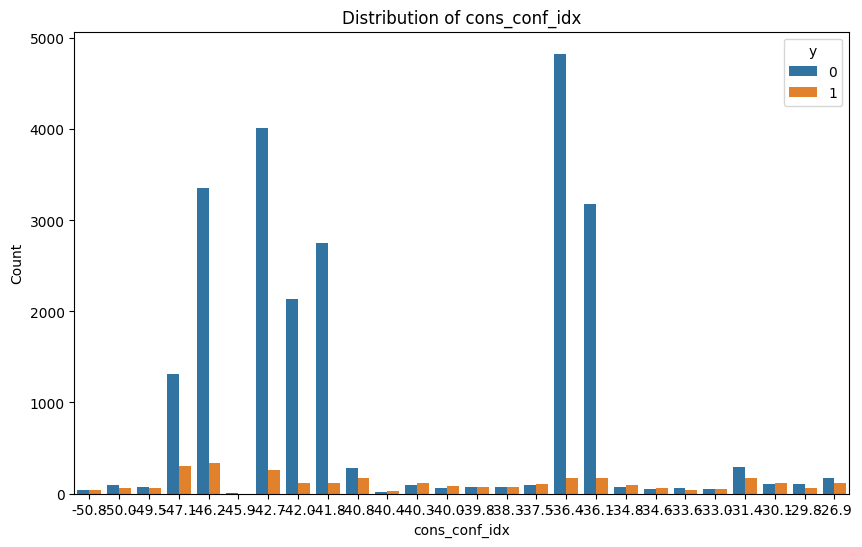

In [12]:
# Histogram of cons_conf_idx variable
plt.figure(figsize=(10, 6))
sns.countplot(x="cons_conf_idx", data=df, hue="y")
plt.title("Distribution of cons_conf_idx")
plt.xlabel("cons_conf_idx")
plt.ylabel("Count")
plt.show()

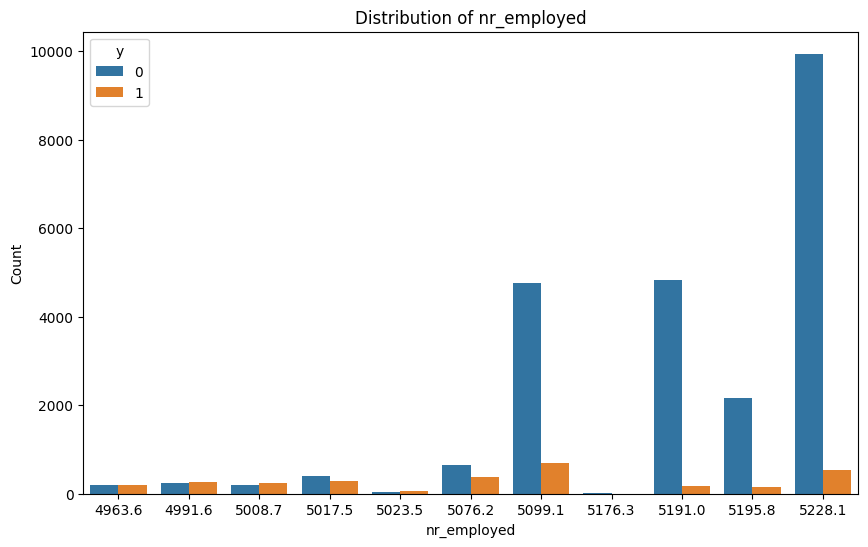

In [13]:
# Histogram of nr_employed variable
plt.figure(figsize=(10, 6))
sns.countplot(x="nr_employed", data=df, hue="y")
plt.title("Distribution of nr_employed")
plt.xlabel("nr_employed")
plt.ylabel("Count")
plt.show()

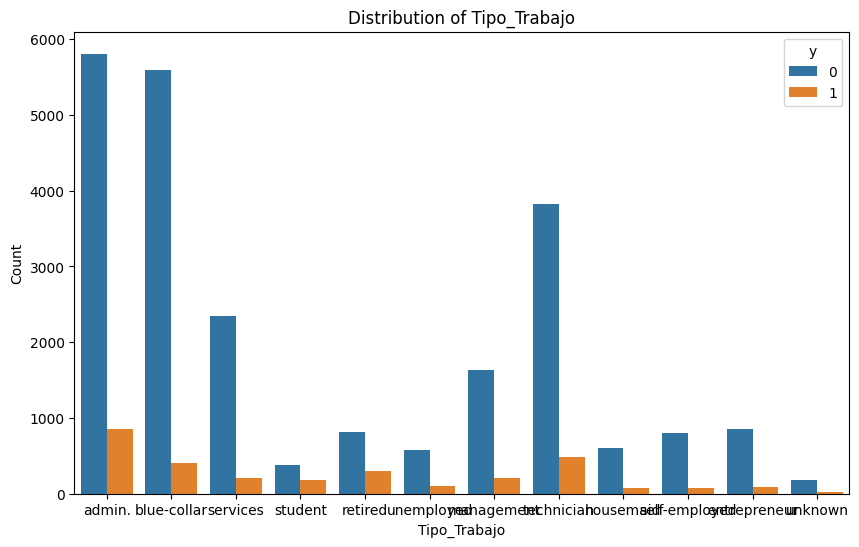

In [14]:
# Histogram of Tipo_Trabajo variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Tipo_Trabajo", data=df, hue="y")
plt.title("Distribution of Tipo_Trabajo")
plt.xlabel("Tipo_Trabajo")
plt.ylabel("Count")
plt.show()

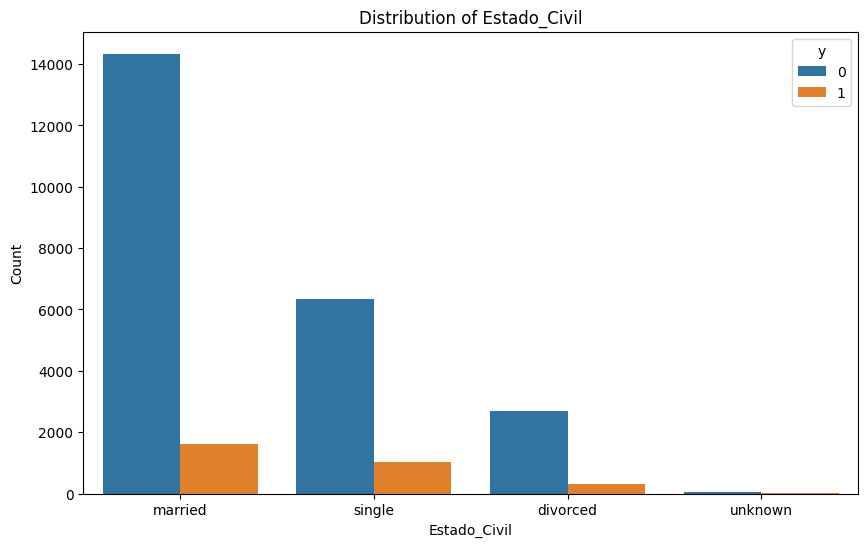

In [15]:
# Histogram of Estado_Civil variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Estado_Civil", data=df, hue="y")
plt.title("Distribution of Estado_Civil")
plt.xlabel("Estado_Civil")
plt.ylabel("Count")
plt.show()

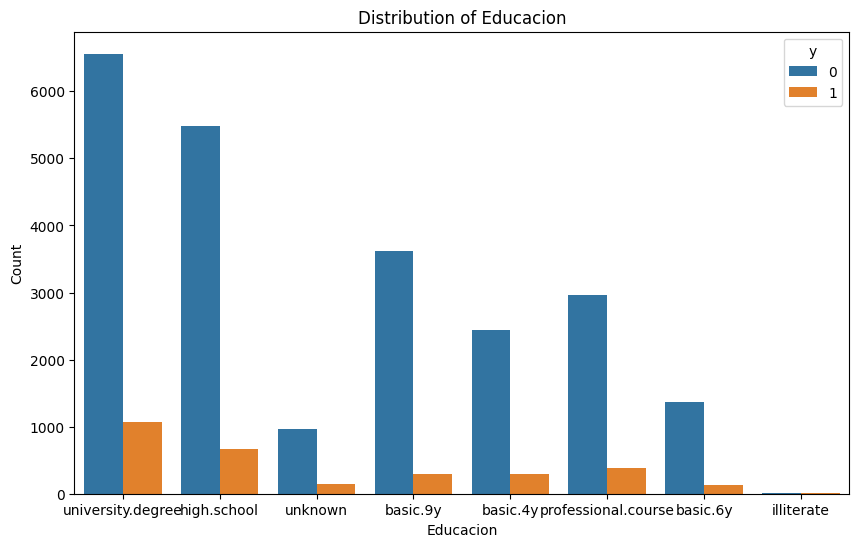

In [16]:
# Histogram of Educacion variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Educacion", data=df, hue="y")
plt.title("Distribution of Educacion")
plt.xlabel("Educacion")
plt.ylabel("Count")
plt.show()

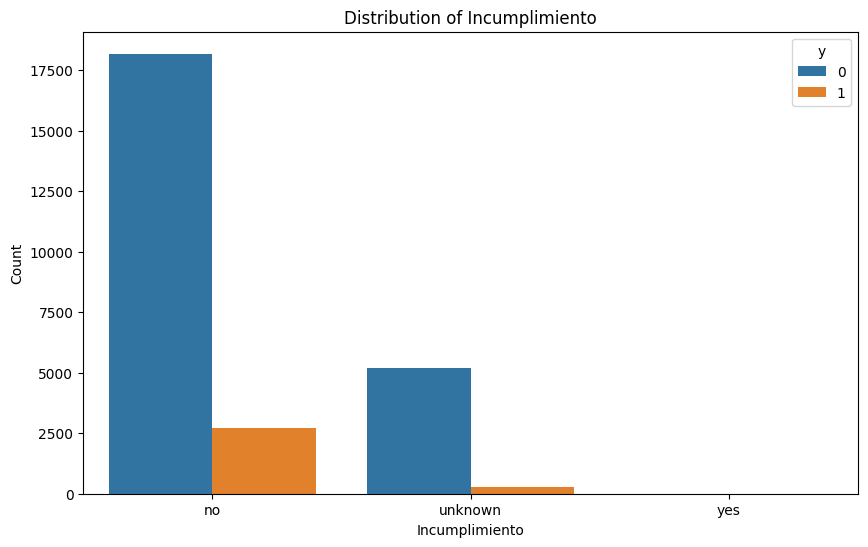

In [17]:
# Histogram of Incumplimiento variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Incumplimiento", data=df, hue="y")
plt.title("Distribution of Incumplimiento")
plt.xlabel("Incumplimiento")
plt.ylabel("Count")
plt.show()

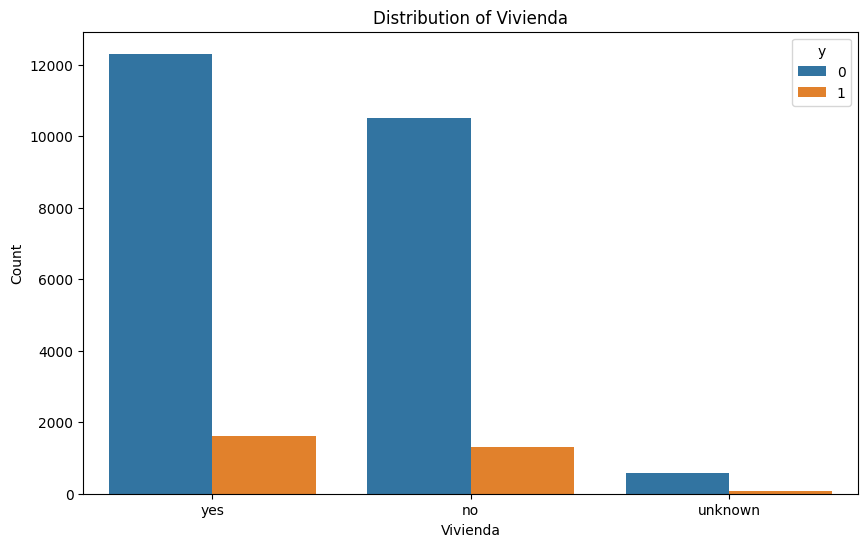

In [18]:
# Histogram of Vivienda variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Vivienda", data=df, hue="y")
plt.title("Distribution of Vivienda")
plt.xlabel("Vivienda")
plt.ylabel("Count")
plt.show()

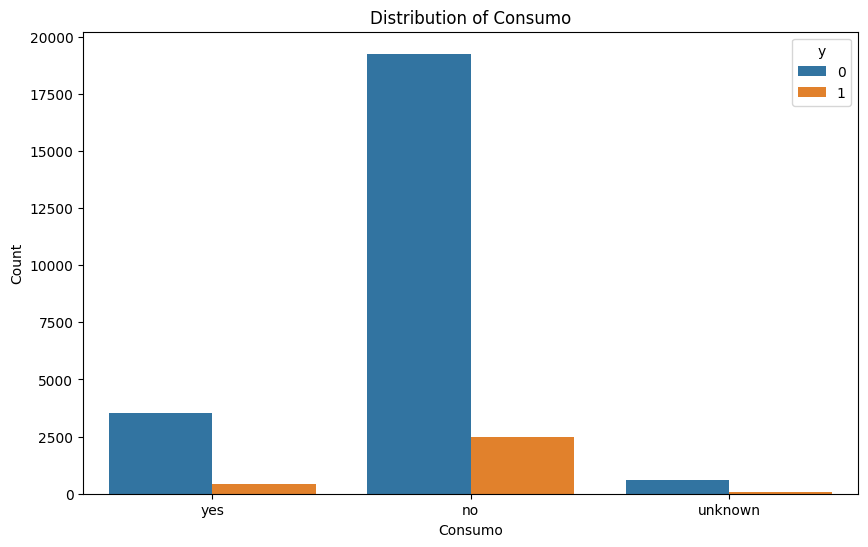

In [19]:
# Histogram of Consumo variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Consumo", data=df, hue="y")
plt.title("Distribution of Consumo")
plt.xlabel("Consumo")
plt.ylabel("Count")
plt.show()

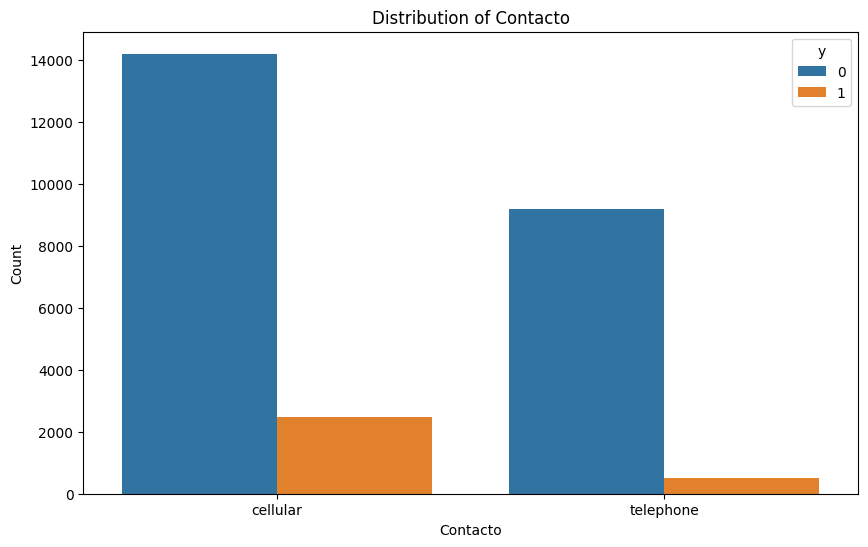

In [20]:
# Histogram of Contacto variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Contacto", data=df, hue="y")
plt.title("Distribution of Contacto")
plt.xlabel("Contacto")
plt.ylabel("Count")
plt.show()

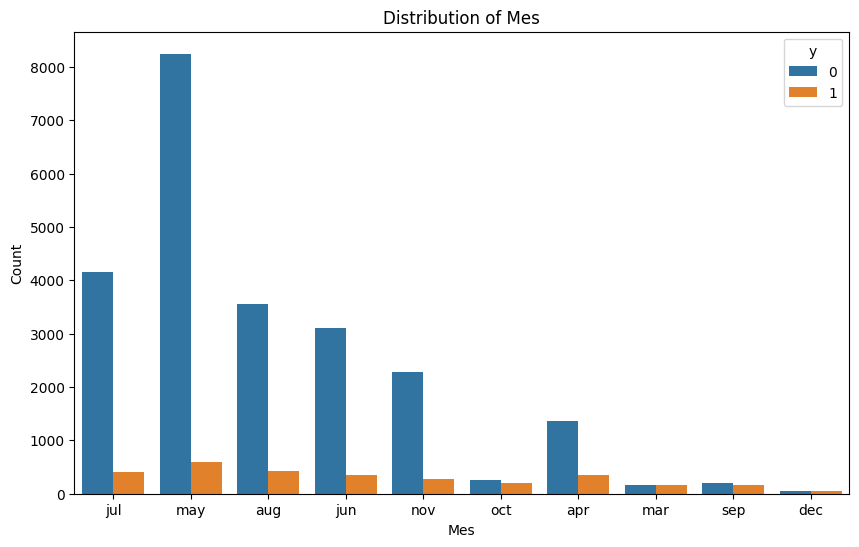

In [21]:
# Histogram of Mes variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Mes", data=df, hue="y")
plt.title("Distribution of Mes")
plt.xlabel("Mes")
plt.ylabel("Count")
plt.show()

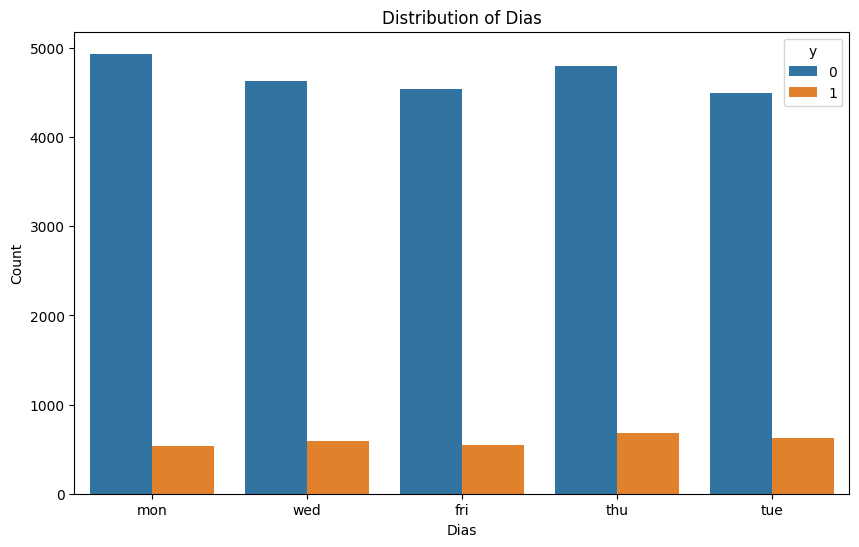

In [22]:
# Histogram of Dias variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Dias", data=df, hue="y")
plt.title("Distribution of Dias")
plt.xlabel("Dias")
plt.ylabel("Count")
plt.show()

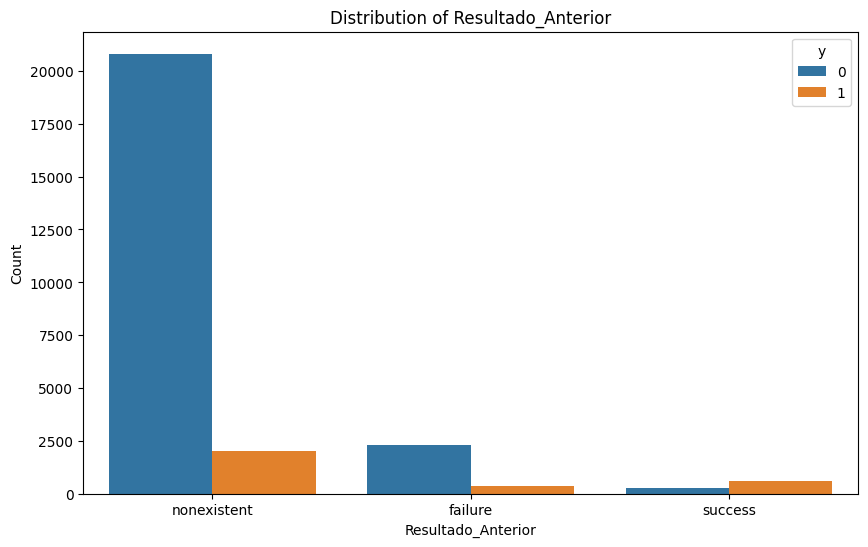

In [23]:
# Histogram of Resultado_Anterior variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Resultado_Anterior", data=df, hue="y")
plt.title("Distribution of Resultado_Anterior")
plt.xlabel("Resultado_Anterior")
plt.ylabel("Count")
plt.show()

# 3. Feature Engineering

## 3.1 One-Hot Encoding

In [24]:
def one_hot_encode(df):
    vars_one_hot = [
        "Tipo_Trabajo",
        "Estado_Civil",
        "Educacion",
        "Incumplimiento",
        "Vivienda",
        "Consumo",
        "Contacto",
        "Mes",
        "Dias",
        "Resultado_Anterior",
    ]
    new_df = pd.DataFrame()
    for var in vars_one_hot:
        dummies = pd.get_dummies(df[var], prefix=var, drop_first=False, dtype=int)
        new_df = pd.concat([new_df, dummies], axis=1)
    return new_df


new_df = one_hot_encode(df)

## 3.2 New Variables

In [ ]:
def new_vars(df, new_df):
    new_df["price_conf_ratio"] = df["cons_price_idx"] / df["cons_conf_idx"]
    new_df["conf_nr_employed_ratio"] = df["cons_conf_idx"] / df["nr_employed"]
    new_df["price_employed_ratio"] = df["cons_price_idx"] / df["nr_employed"]
    new_df["age_euribor_ratio"] = df["Edad"] / df["euribor3m"]
    new_df["total_num_contacts"] = df["No_Contactos"] + df["Campana"]

    num_cols = [
        "Edad",
        "emp_var_rate",
        "cons_price_idx",
        "cons_conf_idx",
        "euribor3m",
        "nr_employed",
        "Campana",
        "Dias_Ultima_Camp",
        "No_Contactos",
    ]
    df_num = df[num_cols]
    new_df = pd.concat([new_df, df_num], axis=1)
    print(f"Shape of new dataframe: {new_df.shape}")
    return new_df


new_df = new_vars(df, new_df)
new_df["y"] = df["y"]

## 3.3 Correlation

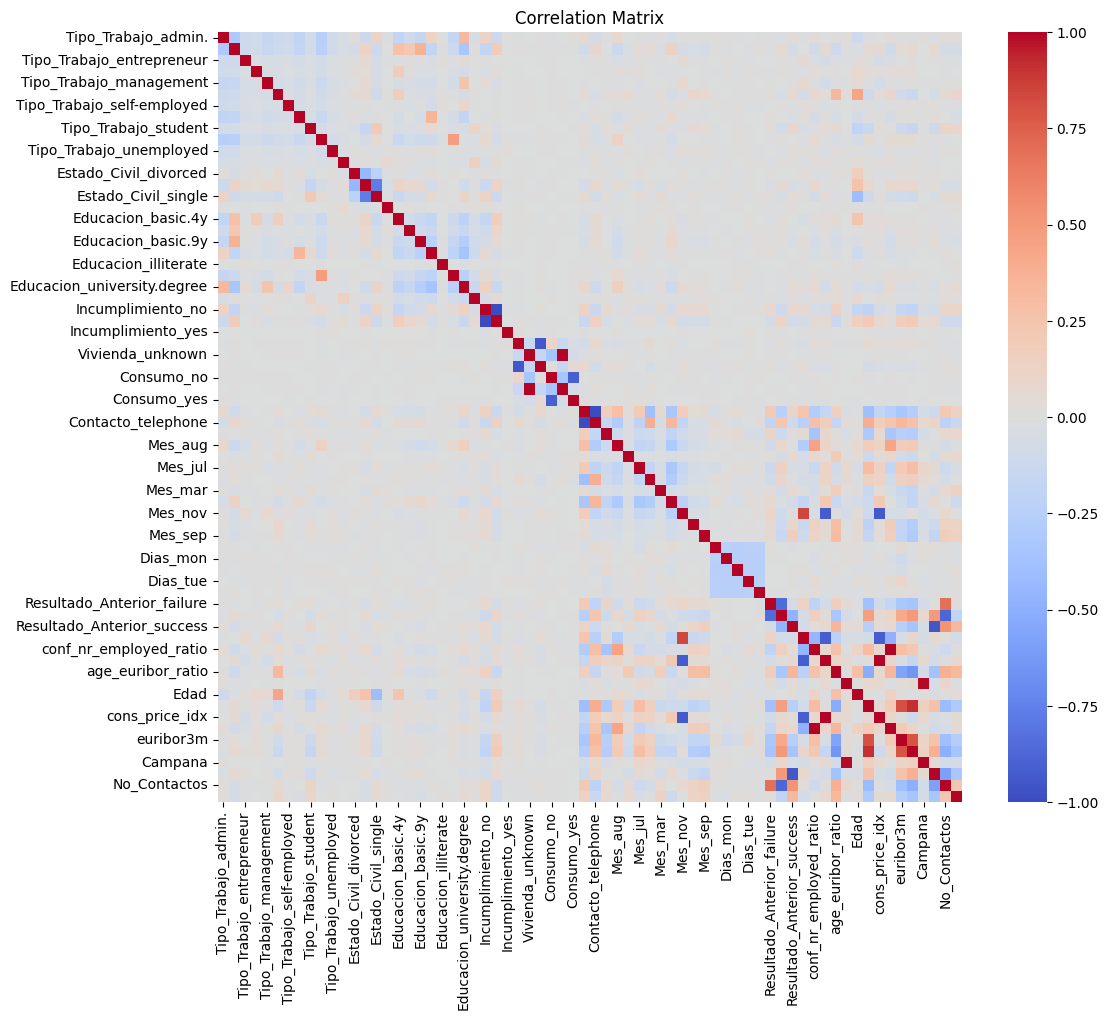

In [26]:
def plot_corr(new_df):
    fig = plt.figure(figsize=(12, 10))
    sns.heatmap(new_df.corr("pearson"), cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation Matrix")
    plt.show()


plot_corr(new_df)

In [27]:
# Avoid low correlation features
def cols_to_drop(new_df):
    low_corr_features = new_df.corr()["y"][new_df.corr()["y"].abs() < 0.05].index
    new_df.drop(columns=low_corr_features, inplace=True)
    print(f"Features dropped due to low correlation: {list(low_corr_features)}")
    # Avoid high correlation features
    high_corr_pairs = new_df.corr().abs().unstack().sort_values(ascending=False)
    high_corr_pairs = high_corr_pairs[high_corr_pairs < 1]
    high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.9]
    to_drop = set()
    for (feat1, feat2), corr in high_corr_pairs.items():
        if feat1 not in to_drop and feat2 not in to_drop:
            if (
                new_df.corrwith(new_df["y"])[feat1]
                > new_df.corrwith(new_df["y"])[feat2]
            ):
                to_drop.add(feat2)
            else:
                to_drop.add(feat1)
    new_df.drop(columns=to_drop, inplace=True)
    cols_to_drop
    print(f"Features dropped due to high correlation: {list(to_drop)}")
    print(f"Shape of dataframe after feature selection: {new_df.shape}")
    return new_df


new_df = cols_to_drop(new_df)

Features dropped due to low correlation: ['Tipo_Trabajo_admin.', 'Tipo_Trabajo_entrepreneur', 'Tipo_Trabajo_housemaid', 'Tipo_Trabajo_management', 'Tipo_Trabajo_self-employed', 'Tipo_Trabajo_services', 'Tipo_Trabajo_technician', 'Tipo_Trabajo_unemployed', 'Tipo_Trabajo_unknown', 'Estado_Civil_divorced', 'Estado_Civil_married', 'Estado_Civil_unknown', 'Educacion_basic.4y', 'Educacion_basic.6y', 'Educacion_high.school', 'Educacion_illiterate', 'Educacion_professional.course', 'Educacion_unknown', 'Incumplimiento_yes', 'Vivienda_no', 'Vivienda_unknown', 'Vivienda_yes', 'Consumo_no', 'Consumo_unknown', 'Consumo_yes', 'Mes_aug', 'Mes_jul', 'Mes_jun', 'Mes_nov', 'Dias_fri', 'Dias_mon', 'Dias_thu', 'Dias_tue', 'Dias_wed', 'Resultado_Anterior_failure', 'conf_nr_employed_ratio', 'total_num_contacts', 'Edad']
Features dropped due to high correlation: ['cons_price_idx', 'nr_employed', 'Dias_Ultima_Camp', 'price_conf_ratio', 'Incumplimiento_unknown']
Shape of dataframe after feature selection: (26

In [28]:
def cols_to_maintain(new_df):
    cols = new_df.columns.tolist()
    return cols


final_cols = cols_to_maintain(new_df)

## 3.5 Standard Scaler

In [29]:
def scaler(new_df, final_cols):
    scaler = StandardScaler()
    num_cols = [col for col in final_cols if col != "y"]
    new_df[num_cols] = scaler.fit_transform(new_df[num_cols])
    return new_df


new_df = scaler(new_df, final_cols)

# 4. Model Evaluation

## 4.1 Train-Test Split

In [30]:
x_train, x_val, target_train, target_val = train_test_split(
    new_df.drop(columns=["y"]),
    new_df["y"],
    test_size=0.3,
    random_state=42,
    stratify=new_df["y"],
)
print(f"Training set shape: {x_train.shape}, Validation set shape: {x_val.shape}")

Training set shape: (18461, 24), Validation set shape: (7912, 24)


In [31]:
x_smote = SMOTE(random_state=42, sampling_strategy=0.8)
x_train_balanced, target_train_balanced = x_smote.fit_resample(x_train, target_train)
print(
    f"Shape of balanced training set: {x_train_balanced.shape}, Shape of balanced target: {target_train_balanced.shape}"
)

Shape of balanced training set: (29476, 24), Shape of balanced target: (29476,)


In [32]:
results = {}
results_balanced = {}

## 4.2 Logistic Regression

In [33]:
def lr_model(x_train, target_train, x_val, target_val, results_dict):
    results_dict["Logistic_Regression"] = {}
    results_dict["Logistic_Regression"]["Parameters"] = None
    results_dict["Logistic_Regression"]["ROC_AUC"] = 0
    penalty = ["l1", "l2", "elasticnet"]
    c_val = [0.01, 0.1, 1]
    score_lr = 0
    for pen in penalty:
        for c in c_val:
            if pen == "elasticnet":
                model = LogisticRegression(
                    penalty=pen,
                    C=c,
                    max_iter=500,
                    l1_ratio=0.5,
                    solver="saga",
                    random_state=42,
                )
            else:
                model = LogisticRegression(
                    penalty=pen, C=c, max_iter=500, solver="saga", random_state=42
                )

            _ = model.fit(x_train, target_train)
            target_pred = model.predict(x_val)
            score = roc_auc_score(target_val, target_pred)
            if score > score_lr:
                score_lr = score
                best_params = {"penalty": pen, "C": c}
                best_model = model
    results_dict["Logistic_Regression"]["Parameters"] = best_params
    results_dict["Logistic_Regression"]["ROC_AUC"] = score_lr
    print(f"ROC-AUC Score: {score_lr}")
    print(
        f"Classification Report:\n  {classification_report(target_val, best_model.predict(x_val))}"
    )
    print(
        f"Confusion Matrix:\n {confusion_matrix(target_val, best_model.predict(x_val))}"
    )

In [34]:
print("Logistic Regression on Original Data:")
lr_model(x_train, target_train, x_val, target_val, results)

Logistic Regression on Original Data:
ROC-AUC Score: 0.6061920874822729
Classification Report:
                precision    recall  f1-score   support

           0       0.91      0.99      0.95      7019
           1       0.68      0.23      0.34       893

    accuracy                           0.90      7912
   macro avg       0.79      0.61      0.64      7912
weighted avg       0.88      0.90      0.88      7912

Confusion Matrix:
 [[6922   97]
 [ 691  202]]


In [35]:
print("Logistic Regression on Balanced Data:")
lr_model(x_train_balanced, target_train_balanced, x_val, target_val, results_balanced)

Logistic Regression on Balanced Data:
ROC-AUC Score: 0.7471586082058186
Classification Report:
                precision    recall  f1-score   support

           0       0.95      0.87      0.91      7019
           1       0.38      0.63      0.47       893

    accuracy                           0.84      7912
   macro avg       0.66      0.75      0.69      7912
weighted avg       0.88      0.84      0.86      7912

Confusion Matrix:
 [[6087  932]
 [ 333  560]]


## 4.3 Random Forest Classifier

In [36]:
def rf_model(x_train, target_train, x_val, target_val, results_dict):
    results_dict["Random_Forest"] = {}
    results_dict["Random_Forest"]["Parameters"] = None
    results_dict["Random_Forest"]["ROC_AUC"] = 0
    estimators = [25, 50, 100, 200, 500]
    depth = [2, 5, 10, 20, None]
    samples_leaf = [1, 2, 4]
    score_rf = 0
    for estimator in estimators:
        for max_depth in depth:
            for min_samples_leaf in samples_leaf:
                model = RandomForestClassifier(
                    n_estimators=estimator,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=42,
                )
                _ = model.fit(x_train, target_train)
                target_pred = model.predict(x_val)
                score = roc_auc_score(target_val, target_pred)
                if score > score_rf:
                    score_rf = score
                    best_params = {
                        "n_estimators": estimator,
                        "max_depth": max_depth,
                        "min_samples_leaf": min_samples_leaf,
                    }
                    best_model = model
    results_dict["Random_Forest"]["Parameters"] = best_params
    results_dict["Random_Forest"]["ROC_AUC"] = score_rf
    print(f"ROC-AUC Score: {score_rf}")
    print(
        f"Classification Report:\n  {classification_report(target_val, best_model.predict(x_val))}"
    )
    print(
        f"Confusion Matrix:\n {confusion_matrix(target_val, best_model.predict(x_val))}"
    )

In [37]:
print("Random Forest on Original Data:")
rf_model(x_train, target_train, x_val, target_val, results)

Random Forest on Original Data:
ROC-AUC Score: 0.641990776275625
Classification Report:
                precision    recall  f1-score   support

           0       0.92      0.96      0.94      7019
           1       0.50      0.33      0.39       893

    accuracy                           0.89      7912
   macro avg       0.71      0.64      0.67      7912
weighted avg       0.87      0.89      0.88      7912

Confusion Matrix:
 [[6725  294]
 [ 602  291]]


In [38]:
print("Random Forest on Balanced Data:")
rf_model(x_train_balanced, target_train_balanced, x_val, target_val, results_balanced)

Random Forest on Balanced Data:
ROC-AUC Score: 0.7462595926238922
Classification Report:
                precision    recall  f1-score   support

           0       0.95      0.88      0.91      7019
           1       0.40      0.61      0.48       893

    accuracy                           0.85      7912
   macro avg       0.67      0.75      0.70      7912
weighted avg       0.89      0.85      0.87      7912

Confusion Matrix:
 [[6208  811]
 [ 350  543]]


## 4.4 Gradient Boosting Classifier

In [39]:
def gb_model(x_train, target_train, x_val, target_val, results_dict):
    results_dict["Gradient_Boosting"] = {}
    results_dict["Gradient_Boosting"]["Parameters"] = None
    results_dict["Gradient_Boosting"]["ROC_AUC"] = 0
    estimators = [25, 50, 100, 200, 500]
    depth = [2, 5, 10, 20]
    learning_rate = [0.01, 0.1, 0.05]
    score_gb = 0
    for estimator in estimators:
        for max_depth in depth:
            for lr in learning_rate:
                model = GradientBoostingClassifier(
                    n_estimators=estimator,
                    max_depth=max_depth,
                    learning_rate=lr,
                    random_state=42,
                )
                _ = model.fit(x_train, target_train)
                target_pred = model.predict(x_val)
                score = roc_auc_score(target_val, target_pred)
                if score > score_gb:
                    score_gb = score
                    best_params = {
                        "n_estimators": estimator,
                        "max_depth": max_depth,
                        "learning_rate": lr,
                    }
                    best_model = model
    results_dict["Gradient_Boosting"]["Parameters"] = best_params
    results_dict["Gradient_Boosting"]["ROC_AUC"] = score_gb
    print(f"ROC-AUC Score: {score_gb}")
    print(
        f"Classification Report:\n  {classification_report(target_val, best_model.predict(x_val))}"
    )
    print(
        f"Confusion Matrix:\n {confusion_matrix(target_val, best_model.predict(x_val))}"
    )

In [40]:
print("Gradient Boosting on Original Data:")
gb_model(x_train, target_train, x_val, target_val, results)

Gradient Boosting on Original Data:
ROC-AUC Score: 0.6348016829061162
Classification Report:
                precision    recall  f1-score   support

           0       0.92      0.97      0.94      7019
           1       0.55      0.30      0.39       893

    accuracy                           0.89      7912
   macro avg       0.73      0.63      0.67      7912
weighted avg       0.87      0.89      0.88      7912

Confusion Matrix:
 [[6797  222]
 [ 624  269]]


In [41]:
print("Gradient Boosting on Balanced Data:")
gb_model(x_train_balanced, target_train_balanced, x_val, target_val, results_balanced)

Gradient Boosting on Balanced Data:
ROC-AUC Score: 0.7414255690880313
Classification Report:
                precision    recall  f1-score   support

           0       0.95      0.88      0.91      7019
           1       0.38      0.61      0.47       893

    accuracy                           0.85      7912
   macro avg       0.66      0.74      0.69      7912
weighted avg       0.88      0.85      0.86      7912

Confusion Matrix:
 [[6148  871]
 [ 351  542]]


## 4.5 XGBoost Classifier

In [42]:
def xgb_model(x_train, target_train, x_val, target_val, results_dict):
    results_dict["XGBoost"] = {}
    results_dict["XGBoost"]["Parameters"] = None
    results_dict["XGBoost"]["ROC_AUC"] = 0
    learning_rate = [0.01, 0.1, 0.05]
    gamma = [0, 0.25, 0.5]
    reg_lambda = [0, 0.5, 1]
    depth = [3, 5, 7, 10]
    subsample = [0.5, 0.75, 0.9]
    score_xgb = 0

    for lr in learning_rate:
        for g in gamma:
            for reg in reg_lambda:
                for d in depth:
                    for s in subsample:
                        model_xgb = xgb.XGBClassifier(
                            learning_rate=lr,
                            gamma=g,
                            reg_lambda=reg,
                            max_depth=d,
                            subsample=s,
                            random_state=42,
                            objective="binary:logistic",
                        )
                        _ = model_xgb.fit(x_train, target_train)
                        target_pred_xgb = model_xgb.predict(x_val)
                        score = roc_auc_score(target_val, target_pred_xgb)
                        if score > score_xgb:
                            score_xgb = score
                            best_params = {
                                "learning_rate": lr,
                                "gamma": g,
                                "reg_lambda": reg,
                                "max_depth": d,
                                "subsample": s,
                            }
                            best_model = model_xgb
    results_dict["XGBoost"]["Parameters"] = best_params
    results_dict["XGBoost"]["ROC_AUC"] = score_xgb
    print(f"ROC-AUC Score: {score_xgb}")
    print(
        f"Classification Report:\n  {classification_report(target_val, best_model.predict(x_val))}"
    )
    print(
        f"Confusion Matrix:\n {confusion_matrix(target_val, best_model.predict(x_val))}"
    )

In [43]:
print("XGBoost on Original Data:")
xgb_model(x_train, target_train, x_val, target_val, results)

XGBoost on Original Data:
ROC-AUC Score: 0.64525618912799
Classification Report:
                precision    recall  f1-score   support

           0       0.92      0.97      0.94      7019
           1       0.59      0.32      0.41       893

    accuracy                           0.90      7912
   macro avg       0.75      0.65      0.68      7912
weighted avg       0.88      0.90      0.88      7912

Confusion Matrix:
 [[6818  201]
 [ 608  285]]


In [44]:
print("XGBoost on Balanced Data:")
xgb_model(x_train_balanced, target_train_balanced, x_val, target_val, results_balanced)

XGBoost on Balanced Data:
ROC-AUC Score: 0.74379196635847
Classification Report:
                precision    recall  f1-score   support

           0       0.94      0.91      0.93      7019
           1       0.44      0.58      0.50       893

    accuracy                           0.87      7912
   macro avg       0.69      0.74      0.71      7912
weighted avg       0.89      0.87      0.88      7912

Confusion Matrix:
 [[6362  657]
 [ 374  519]]


# 5. Final Results

In [45]:
best_unbalanced = max(results, key=lambda x: results[x]["ROC_AUC"])
best_balanced = max(results_balanced, key=lambda x: results_balanced[x]["ROC_AUC"])
print(
    f"Best model on original data: {best_unbalanced} with ROC-AUC: {results[best_unbalanced]['ROC_AUC']}"
)
print(
    f"Best model on balanced data: {best_balanced} with ROC-AUC: {results_balanced[best_balanced]['ROC_AUC']}"
)

Best model on original data: XGBoost with ROC-AUC: 0.64525618912799
Best model on balanced data: Logistic_Regression with ROC-AUC: 0.7471586082058186


In [46]:
best_model = (
    best_unbalanced
    if results[best_unbalanced]["ROC_AUC"] > results_balanced[best_balanced]["ROC_AUC"]
    else best_balanced
)
print(
    f"Overall best model: {best_model} with ROC-AUC: {max(results[best_unbalanced]['ROC_AUC'], results_balanced[best_balanced]['ROC_AUC'])}"
)

Overall best model: Logistic_Regression with ROC-AUC: 0.7471586082058186


## 5.1 ROC-AUC Scores

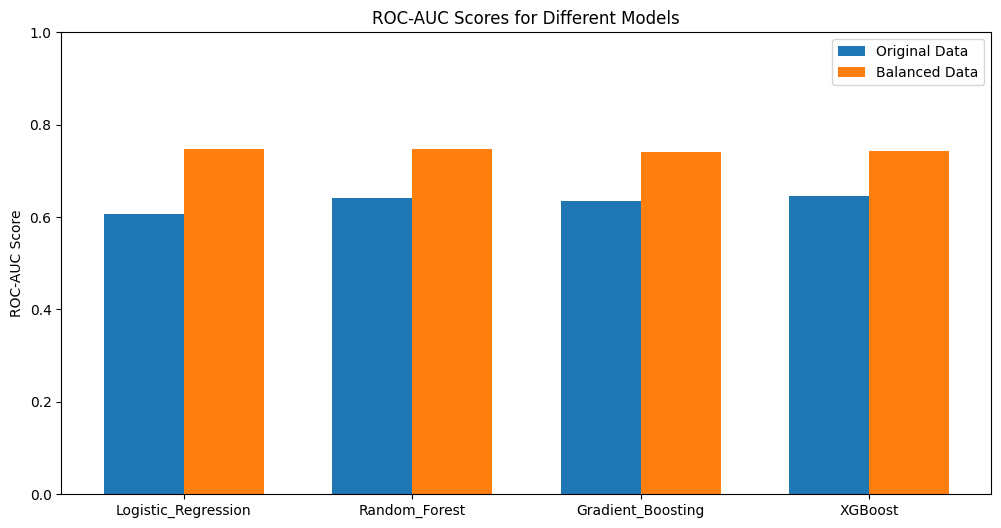

In [47]:
# Plot ROC-AUC scores for all models
model_names = list(results.keys())
roc_scores_unbalanced = [results[model]["ROC_AUC"] for model in model_names]
roc_scores_balanced = [results_balanced[model]["ROC_AUC"] for model in model_names]
x = np.arange(len(model_names))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, roc_scores_unbalanced, width, label="Original Data")
plt.bar(x + width / 2, roc_scores_balanced, width, label="Balanced Data")
plt.xticks(x, model_names)
plt.ylabel("ROC-AUC Score")
plt.title("ROC-AUC Scores for Different Models")
plt.legend()
plt.ylim(0, 1)
plt.show()

## 5.2 Feature Importance

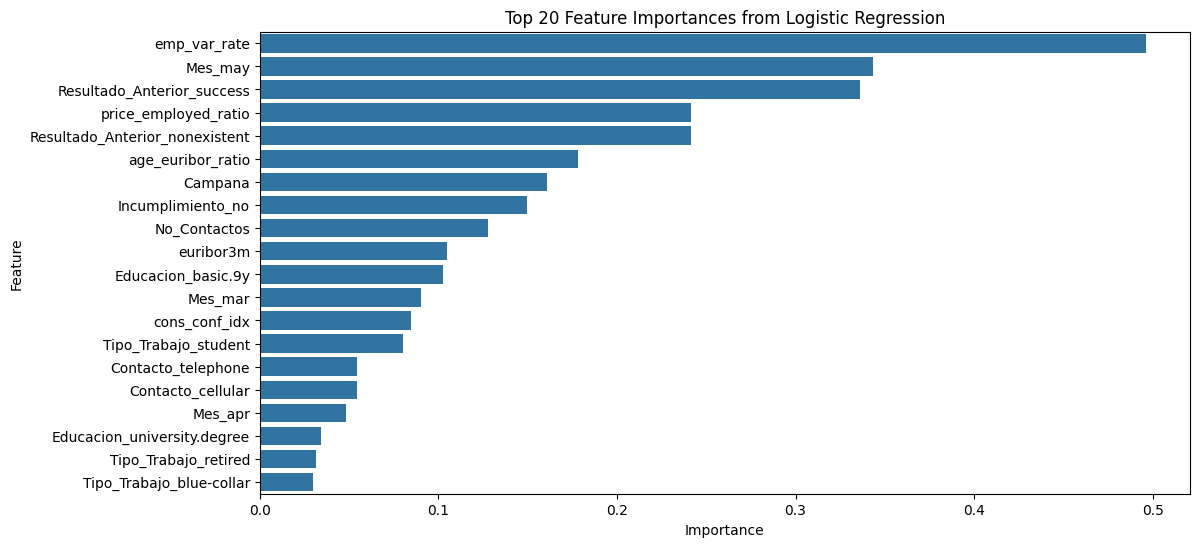

In [48]:
# Plot feature importance for the best model
if best_model == 'XGBoost':
    model = xgb.XGBClassifier(**results[best_model]['Parameters'], 
                              random_state=42, objective="binary:logistic")
    model.fit(x_train, target_train)
    importance = model.feature_importances_
    features = x_train.columns
    feature_importance_df = pd.DataFrame({'Feature': features, 
                                          'Importance': importance})
    feature_importance_df = feature_importance_df.sort_values(by='Importance',
                                                              ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
    plt.title('Top 20 Feature Importances from XGBoost')
    plt.show()
elif best_model == 'Random_Forest':
    model = RandomForestClassifier(**results[best_model]['Parameters'], 
                                   random_state=42)
    model.fit(x_train, target_train)
    importance = model.feature_importances_
    features = x_train.columns
    feature_importance_df = pd.DataFrame({'Feature': features, 
                                          'Importance': importance})
    feature_importance_df = feature_importance_df.sort_values(by='Importance',
                                                              ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
    plt.title('Top 20 Feature Importances from Random Forest')
    plt.show()
elif best_model == 'Gradient_Boosting':
    model = GradientBoostingClassifier(**results[best_model]['Parameters'], 
                                       random_state=42)
    model.fit(x_train, target_train)
    importance = model.feature_importances_
    features = x_train.columns
    feature_importance_df = pd.DataFrame({'Feature': features, 
                                          'Importance': importance})
    feature_importance_df = feature_importance_df.sort_values(by='Importance',
                                                              ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
    plt.title('Top 20 Feature Importances from Gradient Boosting')
    plt.show()
elif best_model == 'Logistic_Regression':
    model = LogisticRegression(**results[best_model]['Parameters'], max_iter=500, 
                                           solver='saga',random_state=42)
    model.fit(x_train, target_train)
    importance = np.abs(model.coef_[0])
    features = x_train.columns
    feature_importance_df = pd.DataFrame({'Feature': features, 
                                          'Importance': importance})
    feature_importance_df = feature_importance_df.sort_values(by='Importance',
                                                              ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
    plt.title('Top 20 Feature Importances from Logistic Regression')
    plt.show()

## 5.3 Prediction Scores

In [50]:
# Predict best model
if best_model == 'XGBoost':
    final_model = xgb.XGBClassifier(**results[best_model]['Parameters'], 
                                    random_state=42, objective="binary:logistic")
elif best_model == 'Random_Forest':
    final_model = RandomForestClassifier(**results[best_model]['Parameters'], 
                                         random_state=42)
elif best_model == 'Gradient_Boosting': 
    final_model = GradientBoostingClassifier(**results[best_model]['Parameters'], 
                                            random_state=42)
elif best_model == 'Logistic_Regression':
    final_model = LogisticRegression(**results[best_model]['Parameters'], random_state=42)
final_model.fit(x_train_balanced, target_train_balanced)
test_predictions = final_model.predict(x_val)
print(f"Final model predictions on validation set:\n {classification_report(target_val, test_predictions)}")

Final model predictions on validation set:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91      7019
           1       0.37      0.63      0.47       893

    accuracy                           0.84      7912
   macro avg       0.66      0.75      0.69      7912
weighted avg       0.88      0.84      0.86      7912



# 6. Train Whole Model

In [51]:
if best_model == 'XGBoost':
    final_model = xgb.XGBClassifier(**results[best_model]['Parameters'], 
                                    random_state=42, objective="binary:logistic")
elif best_model == 'Random_Forest':
    final_model = RandomForestClassifier(**results[best_model]['Parameters'], 
                                         random_state=42)
elif best_model == 'Gradient_Boosting': 
    final_model = GradientBoostingClassifier(**results[best_model]['Parameters'], 
                                            random_state=42)
elif best_model == 'Logistic_Regression':
    final_model = LogisticRegression(**results[best_model]['Parameters'], max_iter=500, 
                                           solver='saga', random_state=42)

x = new_df.drop(columns=['y'])
y = new_df['y']
final_model.fit(x, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [59]:
new_df_test = one_hot_encode(df_test)
new_df_test = new_vars(df_test, new_df_test)
final_cols_test = [col for col in final_cols if col in new_df_test.columns]
new_df_test = new_df_test[final_cols_test]
new_df_test = scaler(new_df_test, final_cols_test)
test_predictions = final_model.predict(new_df_test)
new_submission = pd.DataFrame({'ID': df_test['ID'], 'y': test_predictions})
new_submission.to_csv('new_submission.csv', index=False)

Shape of new dataframe: (6594, 66)
